In [4]:
import os

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from transformers import TrainingArguments, Trainer, DataCollatorForSeq2Seq, Qwen2VLForConditionalGeneration, AutoProcessor, AutoTokenizer
import torch


In [2]:

# print("test:")

# with h5py.File("resource/test_public.h5", "r") as f:
#     print("Keys in file:", list(f.keys()))

#     questions = np.array(f["questions"])
#     print(f"questions shape: {questions.shape}")
#     print(f"First few rows: {questions[:5]}")

#     waveforms = np.array(f["waveforms"])
#     print(f"waveform shape: {waveforms.shape}")
#     print(f"waveforms: {waveforms[0]}")


IMAGE_DIR = "airadio/train_1k/images"

print("train:")
NUM_TRAIN = 1000

# 使用 split.py 划分一个小数据集
with h5py.File("resource/train_1k.h5", "r") as f:
    print("Keys in file:", list(f.keys()))

    labels = np.array(f["labels"])[:NUM_TRAIN]
    print(f"labels shape: {labels.shape}")
    print(f"First few rows: {labels[:5]}")

    waveforms = np.array(f["waveforms"])[:NUM_TRAIN]
    print(f"waveform shape: {waveforms.shape}")
    print(f"waveforms: {waveforms[0]}")


train:
Keys in file: ['labels', 'waveforms']
labels shape: (1000,)
First few rows: [b'[[2427.0, 2447.0], [2422.0, 2432.0], [2422.0, 2432.0], [2427.0, 2447.0]]'
 b'[[2432.0, 2442.0], [2402.0, 2412.0]]'
 b'[[2423.875, 2424.125], [2420.875, 2421.125], [2455.0, 2457.0]]'
 b'[[2422.0, 2462.0], [2402.0, 2442.0]]'
 b'[[2451.0, 2453.0], [2406.875, 2407.125], [2437.0, 2477.0], [2431.0, 2433.0]]']
waveform shape: (1000, 100000)
waveforms: [ 3633.75   +1094.75j    1841.57   -2087.903j   -978.80225-1032.3933j ...
  3684.816  +1735.1885j  2502.5044 -1987.3585j -1170.4862 -1967.5258j]


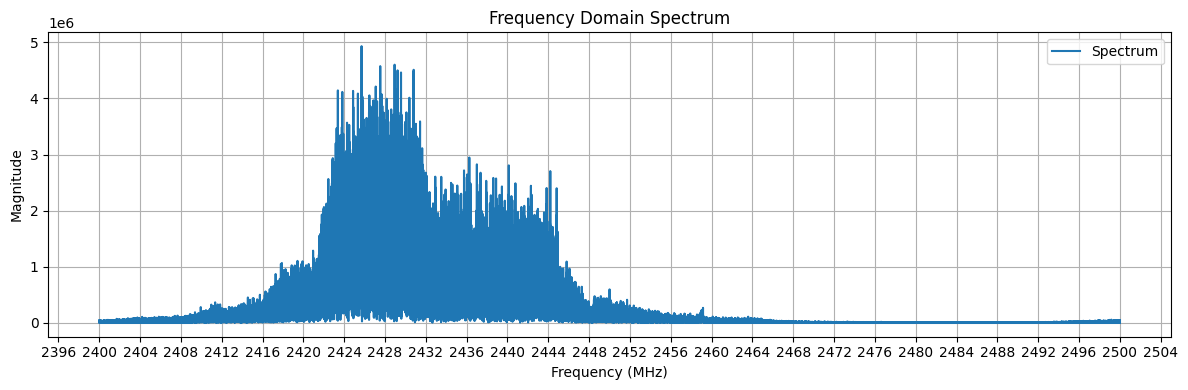

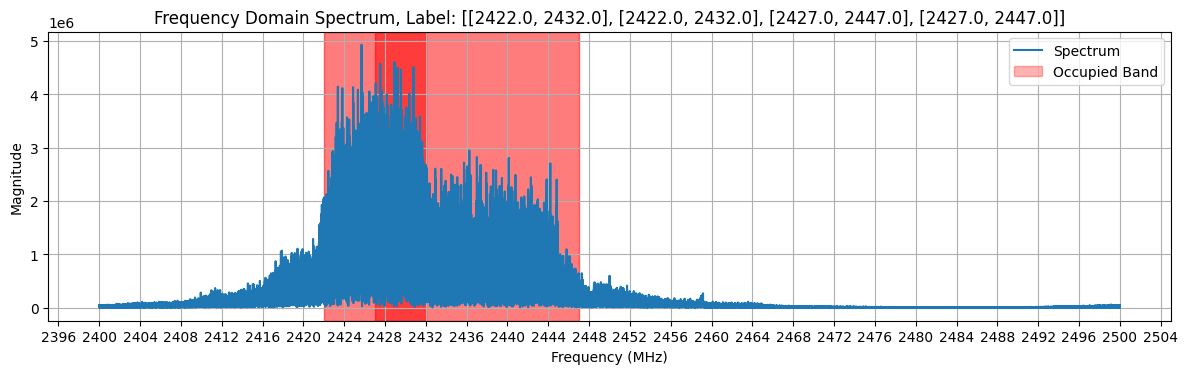

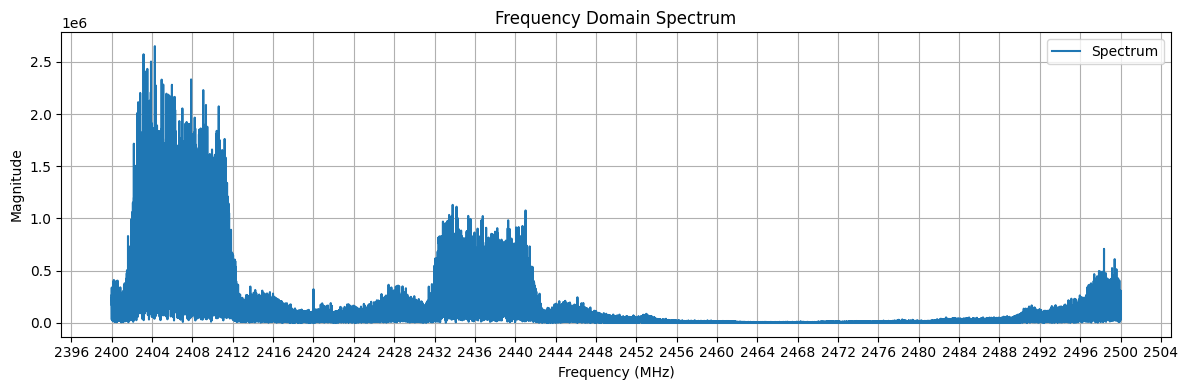

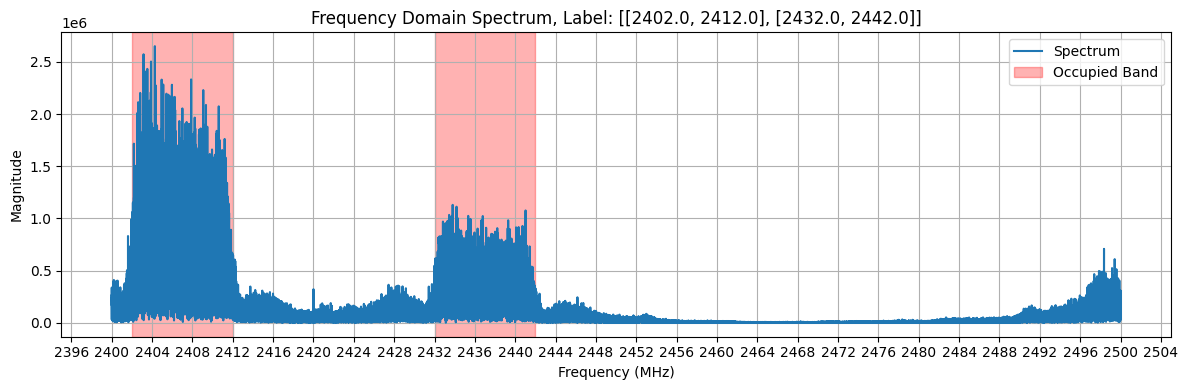

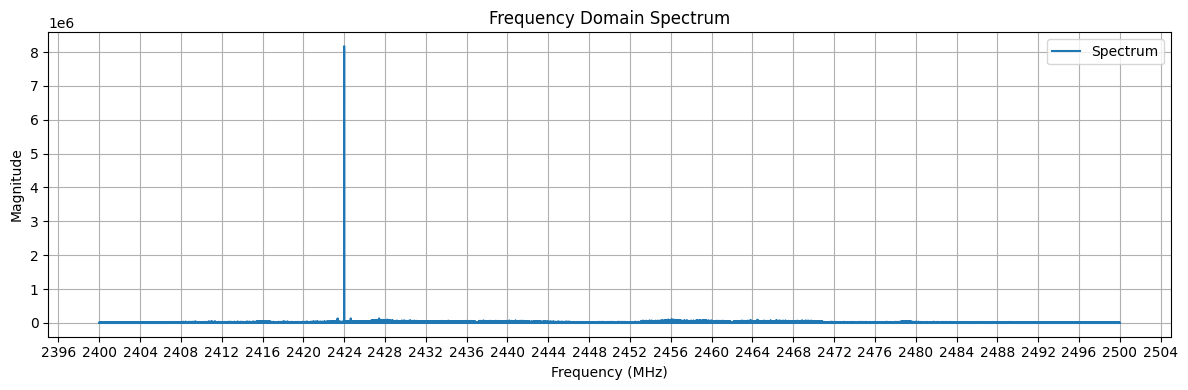

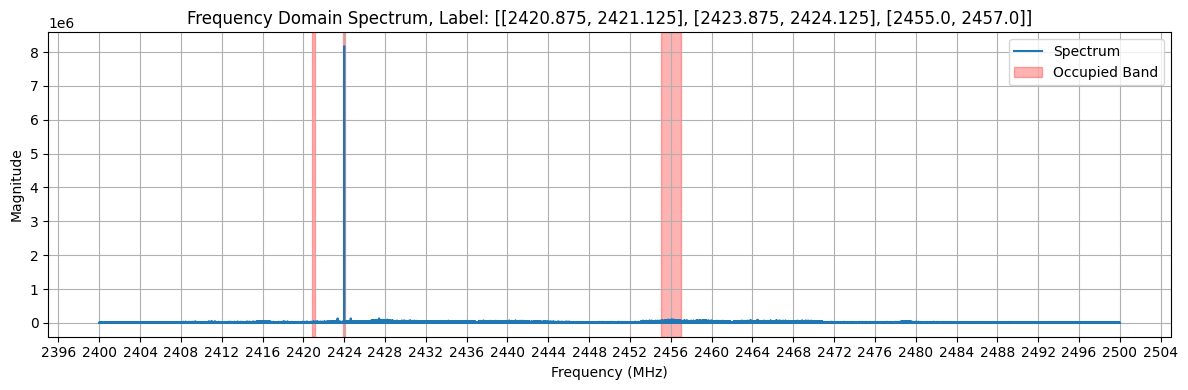

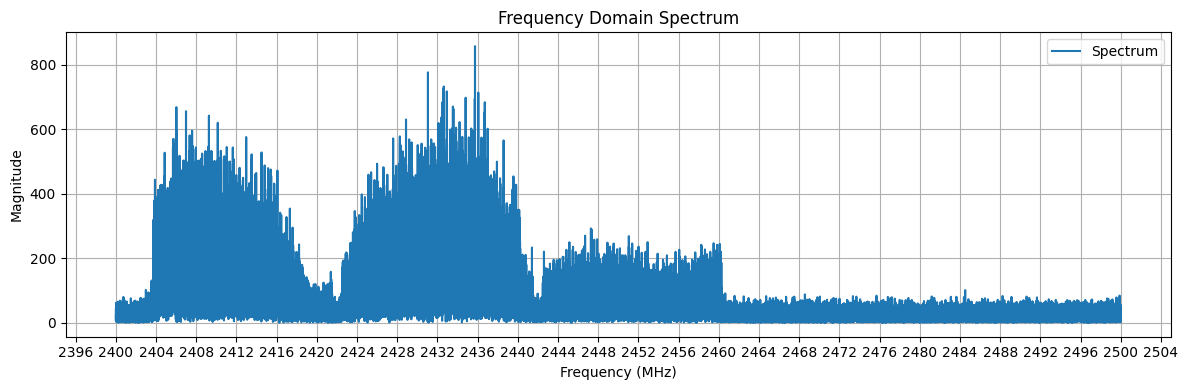

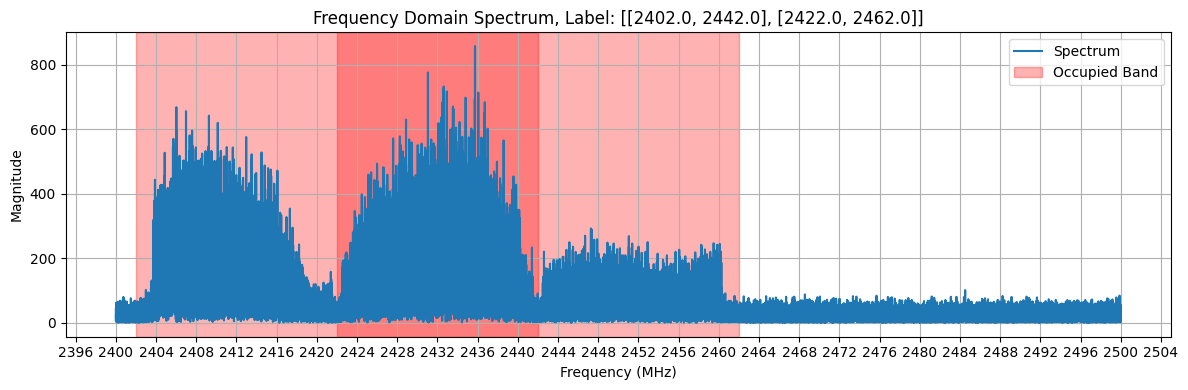

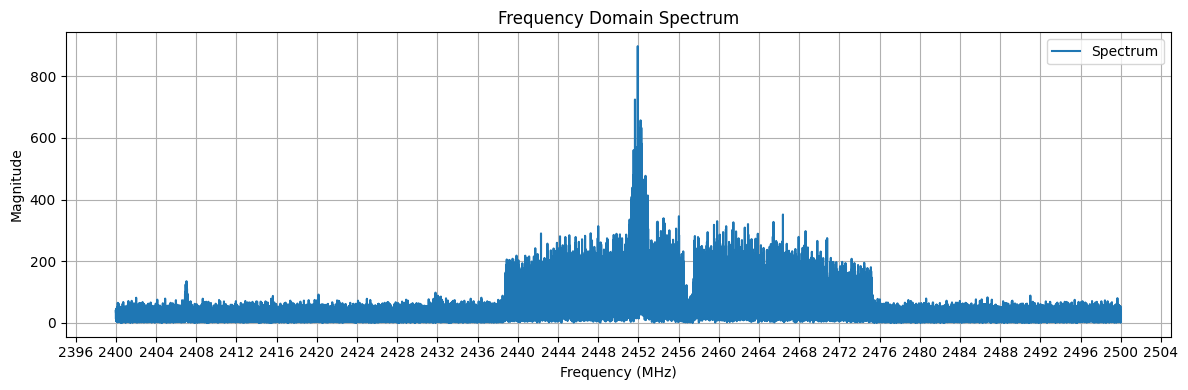

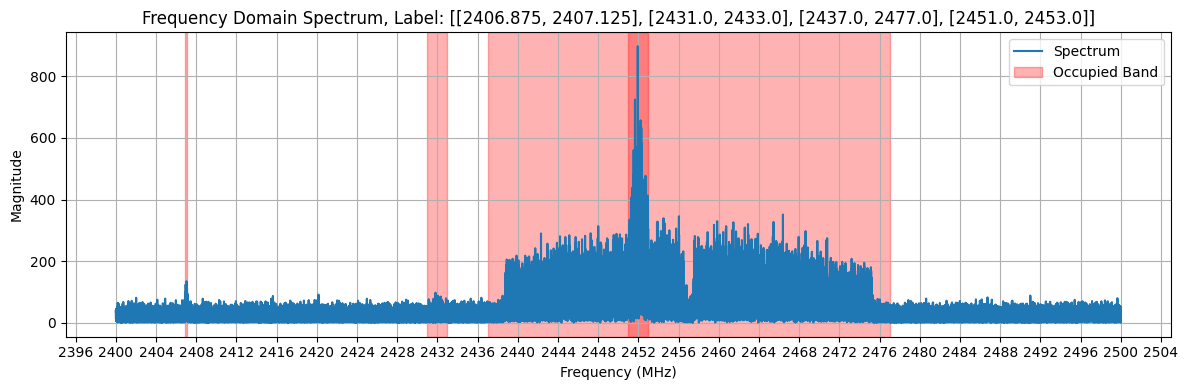

In [3]:
def plot_fft(iq_data, label_str, idx, fs=100e6, f_start=2400e6, f_end=2500e6, show=False, dataset_version="train"):
    """
    对单个 IQ 样本进行 FFT 并可视化为频率域图像。

    参数：
        iq_data (np.array): 一维复数数组，表示 IQ 采样数据。
        label_str (str): 标签字符串，格式如 '[[2402.0, 2422.0], ...]'。
        idx (int): 样本索引，用于文件命名。
        fs (float): 采样率（Hz）
        f_start (float): 起始频率（Hz）
        f_end (float): 结束频率（Hz）
    """
    N = len(iq_data)
    freqs = np.linspace(f_start, f_end, N)
    assert dataset_version in ["train", "vis"], "dataset_version must be 'train' or 'vis'"

    # FFT 计算并移位
    window = np.hanning(N)
    spectrum = np.fft.fft(iq_data * window)
    spectrum = np.fft.fftshift(spectrum)

    # 转换为 MHz 显示
    freqs_mhz = freqs / 1e6
    magnitude = np.abs(spectrum)

    # 解析标签
    occupied_bands = sorted(eval(label_str.tobytes()))

    # 绘图
    plt.figure(figsize=(12, 4))
    plt.plot(freqs_mhz, magnitude, label="Spectrum")

    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Magnitude")

    if dataset_version == "vis":
        for band in occupied_bands:
            plt.axvspan(band[0], band[1], color='red', alpha=0.3, label="Occupied Band")

        plt.title(f"Frequency Domain Spectrum, Label: {occupied_bands}")
    else:
        plt.title(f"Frequency Domain Spectrum")

    plt.grid(True)

    # 去重图例
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())

    # 增加 x 轴刻度
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MultipleLocator(4))

    plt.tight_layout()
    if not os.path.exists(IMAGE_DIR):
        os.makedirs(IMAGE_DIR)
    if not os.path.exists(os.path.join(IMAGE_DIR, dataset_version)):
        os.makedirs(os.path.join(IMAGE_DIR, dataset_version))
    image_path = os.path.join(IMAGE_DIR, dataset_version, f"spectrum_{idx}.png")
    plt.savefig(image_path)
    if show:
        plt.show()
    plt.close()


NUM_VISUALIZE = 10
for i in range(NUM_VISUALIZE):
    label_str = labels[i]
    waveform = waveforms[i]
    plot_fft(waveform, label_str, i, show=i<5, dataset_version="train")
    plot_fft(waveform, label_str, i, show=i<5, dataset_version="vis")
    print(f"Processed {i + 1}/{NUM_VISUALIZE} samples.", end="\r")


In [6]:
# 使用Transformers加载模型权重
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2-VL-2B-Instruct", use_fast=False, trust_remote_code=True)
# 特别的，Qwen2-VL-2B-Instruct模型需要使用Qwen2VLForConditionalGeneration来加载
model = Qwen2VLForConditionalGeneration.from_pretrained("Qwen/Qwen2-VL-2B-Instruct", device_map="auto", torch_dtype=torch.bfloat16, trust_remote_code=True,)
model.enable_input_require_grads()  # 开启梯度检查点时，要执行该方法

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
`Qwen2VLRotaryEmbedding` can now be fully parameterized by passing the model config through the `config` argument. All other arguments will be removed in v4.46
Loading checkpoint shards: 100%|██████████| 2/2 [00:05<00:00,  2.83s/it]
Some parameters are on the meta device device because they were offloaded to the cpu.
